## Factorial of a Number

The **factorial** of a non-negative integer \(n\), written as \(n!\), is the product of all positive integers from \(1\) to \(n\).

$$
n! = 1 \times 2 \times 3 \times \cdots \times n \qquad (n \ge 1)
$$

By definition,

$$
0! = 1
$$

### Examples

- \(1! = 1\)  
- \(3! = 3 x 2 x 1 = 6\)  
- \(5! = 5 x 4 x 3 x 2 x 1 = 120\)

### Recursive Definition

Factorial can also be defined recursively as:

$$
n! = n \times (n-1)! \qquad \text{for } n \ge 1,\quad \text{with } 0! = 1
$$

In [5]:
# Calculates the surface area and volume of a sphere
n=int(input("Enter an integer: "))
p=1
i=1
while True:
    p*=i
    if n==0 or i==n:
        break
    i+=1
print("The factorial of "+str(n)+" is "+str(p))

Enter an integer:  6


The factorial of 6 is 720


## Python Program: Surface Area and Volume of a Sphere

This program defines a function `calculate(diameter)` that computes the **surface area** and **volume** of a sphere given its **diameter**. It then asks the user to input the diameter, calls the function, and prints the results.


In [11]:
def calculate(diameter):
# Calculates the surface area and volume of a sphere
    radius=diameter/2
    pi=3.14159
    surface_area=4*pi*radius**2
    volume=(4/3)*pi*radius**3
    return [surface_area, volume]
diameter=int(input("Enter diameter: "))
ans=calculate(diameter)
print("The surface area of the sphere of diameter "+str(diameter)+
" is "+str(ans[0])+" and volume is "+str(ans[1]))

Enter diameter:  5


The surface area of the sphere of diameter 5 is 78.53975 and volume is 65.44979166666666


## Euler method

Euler method is the simplest numerical method to solve first-order ODE.

Consider a first-order ODE of the form

$$
\frac{dy}{dx} = f(x, y) \qquad (3.7)
$$

with the given initial condition as $y = y_0$ at $x = x_0$. This piece of information is needed for unique solution of the equation (3.7). Using Taylor series expansion about $x_0$, the value of the dependent variable ($y$) is evaluated at $x = x_0 + h$ as follows:

$$
y(x_0 + h) = y(x_0) + h y'(x_0) + \frac{h^2}{2!}y''(x_0) + \frac{h^3}{3!}y'''(x_0) + \cdots \qquad (3.8)
$$

where $h$ is the increment, and $y'(x_0), y''(x_0)$ etc. are obtained from the function $f(x, y)$ and its derivatives respectively at $(x_0, y_0)$. Algorithm for the Euler method is obtained by truncating the higher order terms of equation (3.8), i.e.,

$$
y(x_0 + h) = y(x_0) + h y'(x_0) + \text{Error}
$$

or,

$$
y(x_0 + h) = y(x_0) + h f(x_0, y_0) + \text{Error}
$$

Generalizing the above expression, the algorithm for Euler method is

$$
y_{n+1} = y_n + h f(x_n, y_n) \qquad (3.9)
$$

where $y_{n+1}$ is the value of $y$ to be calculated for $x = x_n + h$ using $y_n$ at $x = x_n$, value of the function at $(x_n, y_n)$, and step size $h$. The process starts with the initial condition and repeats until desired range of $x$ is reached.

## Free Fall under gravity.

Consider an object of mass $m$ that falls freely under gravity. Therefore, ignoring air resistance and using Newton's 2nd law of motion, we can formulate the mathematical model as

$$
m\frac{dv}{dt} = mg
$$

where the force on the right-hand side is replaced by $mg$. Note that vector notation is dropped in this case. Therefore,

$$
\frac{dv}{dt} = g \qquad (3.10)
$$

Analytically, the solution of this ODE is $v = gt + c$, where $c$ is an integration constant, to be determined from the initial condition. Otherwise, this analytical solution gives us a set of straight lines with slope $g$ if we plot $t$ on the $x$-axis and $v$ along the $y$-axis. Once we put an initial condition (say, at $t = 0$, $v = 0$) we get a particular solution

$$
v = gt \qquad (3.11)
$$

a straight line passing through the origin. It shows that velocity of the particle increases continuously with time. This is, however, not realistic, as we will see in the next application.

The model takes the form as given below

$$
m\frac{dv}{dt} = mg
$$

with the initial condition $v = 0$ at $t = 0$. Here $v$ is the instantaneous velocity of the object and $g$ is the acceleration due to gravity. The above equation can be written as

$$
\frac{dv}{dt} = f(v, t)
$$

where $f(v, t) = g$, a constant. Using the Euler algorithm as given in equation (3.9), velocity of the object can be computed following the equation

$$
v_{n+1} = v_n + h\, f(t_n, v_n)
$$

For the first time step, if we take $v_{n+1}$ to be the velocity of the object at time $\Delta t$, then $v_n$ will be the velocity of the object at the initial time, i.e., at $t = 0$. Here $h$ is actually $\Delta t$ and the function $f(v, t)$, in this case, is $g$. Once velocity at time $\Delta t$ is calculated, we can calculate velocity at time $2\Delta t$ using the value of velocity at $\Delta t$. The process continues until $t = 5~\text{s}$.

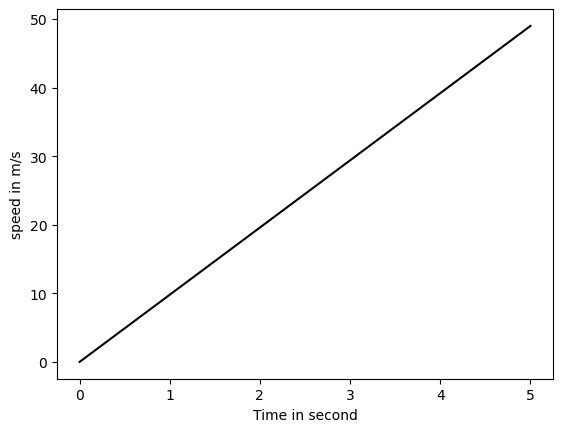

In [3]:
import matplotlib.pyplot as plt
import numpy as np

g, t, v, h = 9.8, 0.0, 0.0, 0.5

with open("euler.txt", "w") as euler_data:
    while t <= 5:
        euler_data.write(f"{t},{v}\n")   
        v += h * g                       # dv/dt = g
        t += h

x, y = np.loadtxt("euler.txt", delimiter=",", unpack=True)

plt.plot(x, y, "k")
plt.xlabel("Time in second")
plt.ylabel("speed in m/s")
plt.show()

## Motion of a particle in resistive medium

Consider motion of an object through air whose resistive force is to be taken into account. The resistive force depends on both the speed and geometry of the object. We may take the resistive force as follows:

$$
\vec{F}_r(\vec{v}) = -\left(a_0 + a_1 v + a_2 v^2 + \cdots \right)\,\hat{v} \qquad (3.12)
$$

where $\vec{F}_r$ is the resistive or frictional force, $v$ is the speed of the object and $\hat{v}$ is the unit vector along the direction of $\vec{v}$. The negative sign indicates that it always opposes the motion of the object. The above equation can be written in the component form instead of vector form along three different directions.

The constant term in the right-hand side is the constant kinetic friction while the second term, proportional to speed of the object, represents damping. Assuming the object as a particle we can avoid dependency of the resistive force on the geometry of the object. Again we take the direction of motion as the negative $z$-direction so that an interesting result can be obtained.

Considering speed of the particle is less, the resistive force is taken to be proportional to speed of the particle. Therefore, the mathematical model for the problem is expressed as

$$
m\frac{dv}{dt} = mg - a_1 v
$$

Rearranging we can write

$$
\frac{dv}{dt} = g - \lambda v \qquad (3.13)
$$

where $\lambda = \frac{a_1}{m}$ is a constant for a particular particle of mass $m$. Equation (3.13) is a first-order ODE and has analytical solution of the form

$$
v(t) = \frac{g}{\lambda}\left(1 - e^{-\lambda t}\right),
\quad \text{if the particle is initially released from rest.}
$$

The analytical solution shows that velocity of the particle increases with time and finally approaches to a fixed value $\frac{g}{\lambda}$ as $t \to \infty$. In practice, as we will see in an example given here, the particle approaches this fixed value after sometime and remain almost constant thereafter. This constant velocity of the particle is known as **terminal velocity**.

A particle moves with a constant velocity (here termed as terminal velocity) when according to Newton's law of motion, the net force acting on the particle is zero. The resistive force of air increases with time and whenever this opposing force becomes equal to force due to gravity, the particle attains the terminal velocity.

According to the given problem, the motion of the particle is described by an ODE as follows:

$$
\frac{dv}{dt} = g - \lambda v
$$

As the particle is released from rest, the initial condition becomes $v = 0$ at $t = 0$. We will solve this equation numerically using the Euler algorithm. Here the function $f(v, t) = g - \lambda v$. The following Python program computes velocity of the particle for $\lambda = 1, 2,$ and $3$.

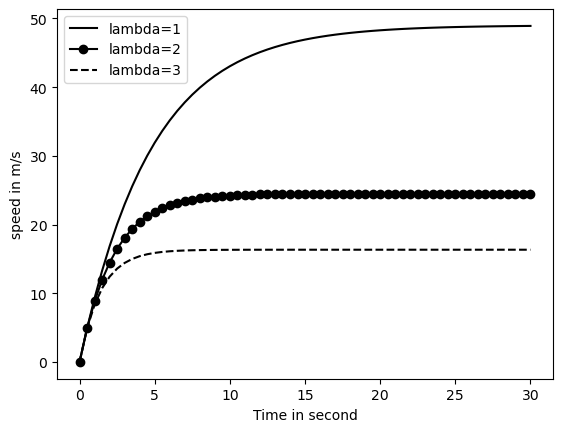

In [75]:
import matplotlib.pyplot as plt
import numpy as np

m = 5
a = (1, 2, 3)   # a values
marker = ['k-', 'ko-', 'k--']

for i in a:
    lam = i / m
    g, t, v, h = 9.8, 0, 0, 0.5

    with open("euler2.txt", "w") as euler_data_2:
        def f(t, v):
            return g - lam * v

        while t <= 30:
            euler_data_2.write(f"{t},{v}\n")
            v += h * f(t, v)
            t += h

    x, y = np.loadtxt("euler2.txt", delimiter=",", unpack=True)
    plt.plot(x, y, marker[i - 1], label="lambda=" + str(i))

plt.xlabel("Time in second")
plt.ylabel("speed in m/s")
plt.legend()
plt.show()

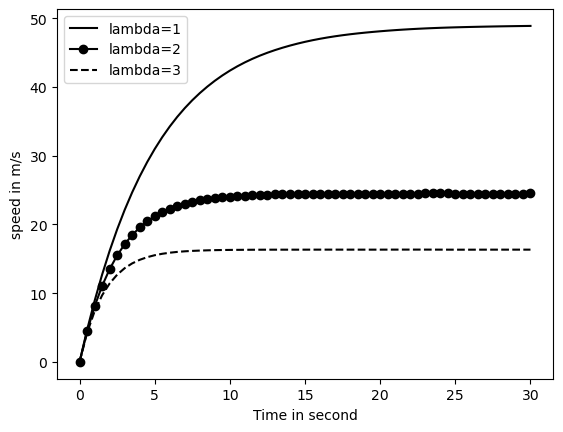

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

m = 5
a = (1, 2, 3)
marker = ['k-', 'ko-', 'k--']

g = 9.8
t_span = (0, 30)
t_eval = np.arange(0, 30.0 + 0.5, 0.5)
v0 = [0.0]

for i in a:
    lam = i / m

    def dvdt(t, v):
        return g - lam * v[0]

    sol = solve_ivp(dvdt, t_span, v0, t_eval=t_eval, method="RK45")

    plt.plot(sol.t, sol.y[0], marker[i-1], label=f"lambda={i}")

plt.xlabel("Time in second")
plt.ylabel("speed in m/s")
plt.legend()
plt.show()

Reference: Lohar, D. (2019) Computational Methods for Physics. 1st edn. Kolkata, West Bengal:  Medtech. 